# Q1 Prompt Engineering: Per-Session Progress Scoring

**Pipeline:**

```
test_notes.json      ──► V1 prompt ──► v1_scores.csv  ──► evaluate  (Q1a: baseline)
                     ──► V2 prompt ──► v2_scores.csv  ──► evaluate  (Q1a: final)
unlabeled_notes.json ──► V2 prompt ──► unlabeled_scores.csv ──► scored_notes.csv  (Q1b)
```

**Report metadata:**
- **LLM used:** Claude Opus 4.6
- **Approach:** Manual — upload JSON file, paste prompt, parse CSV response
- **Prompt strategies implemented (V2):**
  1. Persona / role assignment ("You are an expert evaluator of SLP therapy progress…")
  2. Explicit score definitions anchored to observable clinical behaviours
  3. Few-shot examples drawn from the labeled set (3 clients with known gold scores)
  4. Output format constraint (exact CSV header enforced, no markdown, no explanation)

In [57]:
from pathlib import Path
import json, csv, io, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    mean_absolute_error,
)
from scipy.stats import spearmanr

plt.style.use("seaborn-v0_8-whitegrid")

# ── Config (mirrors BaseQ1Config from q1.py) ───────────────────────────────
VALID_SCORES   = (0, 1, 2, 3)   # gold labels use 0-3
N_TRANSITIONS  = 11             # 12 notes → 11 scored pairs

GOLD_PATH            = Path("data/labeled_notes.json")
UNLABELED_PATH       = Path("data/unlabeled_notes.json")
V1_SCORES_PATH       = Path("data/v1_scores.csv")
V2_SCORES_PATH       = Path("data/v2_scores.csv")
UNLABELED_SCORES_PATH = Path("data/unlabeled_scores.csv")
SCORED_NOTES_PATH    = Path("data/scored_notes.csv")

TRANSITION_COLS = [f"t{i}_{i+1}" for i in range(1, 12)]

print("Imports OK")

Imports OK


## Helper Functions

Ported from `q1.py` — data loading, vector alignment, confusion matrix builder, metrics.

In [58]:
# ── Data loading ───────────────────────────────────────────────────────────
def load_gold(path: Path) -> dict:
    """Load labeled_notes.json → {client_id: [11 scores]}."""
    data = json.loads(path.read_text(encoding="utf-8"))
    return {item["client_id"]: item["scored_progress"] for item in data}


def load_llm_csv(path: Path) -> dict:
    """
    Load a wide-format CSV produced by the LLM (Claude Opus 4.6).
    Expected header: client_id,t1_2,t2_3,...,t11_12
    Returns {client_id: [11 ints]}.
    """
    df = pd.read_csv(path)
    # Normalise column names: accept t1_2 or t1-2 or transition_1 etc.
    df.columns = [c.strip().lower().replace("-", "_") for c in df.columns]
    score_cols = [c for c in df.columns if c != "client_id"]
    result = {}
    for _, row in df.iterrows():
        scores = [int(row[c]) for c in score_cols]
        result[str(row["client_id"]).strip()] = scores
    return result


# ── Alignment ──────────────────────────────────────────────────────────────
def align(gold: dict, pred: dict) -> tuple:
    """
    Return flat (y_true, y_pred, step_rows) over all shared clients.
    step_rows mirrors the step_level_comparisons structure in q1.py.
    """
    shared = sorted(set(gold) & set(pred))
    if not shared:
        raise ValueError("No shared client_ids between gold and predictions.")

    y_true, y_pred, rows = [], [], []
    for cid in shared:
        for step, (t, p) in enumerate(zip(gold[cid], pred[cid]), start=1):
            y_true.append(t); y_pred.append(p)
            rows.append({"client_id": cid, "step_number": step,
                         "true_score": t, "estimated_score": p})
    return y_true, y_pred, rows, shared


# ── Metrics (TODO 3 from q1.py) ────────────────────────────────────────────
def compute_metrics(y_true, y_pred, label="") -> dict:
    """
    Compute evaluation metrics for ordinal progress scores.

    Primary metric: Quadratic Weighted Kappa (QWK)
      - Respects ordinal ordering (0 < 1 < 2 < 3)
      - Penalises larger disagreements more than near misses
      - Measures agreement beyond chance, which matters when class
        frequencies are uneven (score 0 dominates)

    Supporting metrics: exact accuracy, MAE, within-1 accuracy, Spearman.
    """
    qwk      = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    mae      = mean_absolute_error(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    within1  = np.mean(np.abs(np.array(y_true) - np.array(y_pred)) <= 1)
    spearman = spearmanr(y_true, y_pred).statistic

    if label:
        print(f"\n=== {label} ===")
    print(f"  QWK (primary) : {qwk:.3f}")
    print(f"  Accuracy      : {accuracy:.3f} ({accuracy:.1%})")
    print(f"  MAE           : {mae:.3f}")
    print(f"  Within-1 acc  : {within1:.3f} ({within1:.1%})")
    print(f"  Spearman r    : {spearman:.3f}")

    return {"qwk": qwk, "accuracy": accuracy, "mae": mae,
            "within1": within1, "spearman": spearman}


# ── Confusion matrix (mirrors build_confusion_matrix from q1.py) ───────────
def plot_confusion(y_true, y_pred, title=""):
    labels = list(VALID_SCORES)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, fmt, t in zip(
        axes,
        [cm, cm_norm],
        ["d", ".2f"],
        ["Counts", "Row-normalised"],
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(t)

    fig.suptitle(title or "Confusion Matrix", fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Printable table (mirrors q1.py build_confusion_matrix output)
    cm_df = pd.DataFrame(cm,
        index=[f"True {s}" for s in labels],
        columns=[f"Pred {s}" for s in labels])
    display(cm_df)
    return cm


# ── Per-transition position analysis ──────────────────────────────────────
def plot_per_transition(y_true, y_pred, n_clients, title=""):
    true_arr = np.array(y_true).reshape(n_clients, N_TRANSITIONS)
    pred_arr = np.array(y_pred).reshape(n_clients, N_TRANSITIONS)
    positions = range(1, N_TRANSITIONS + 1)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(positions, true_arr.mean(axis=0), "o-", label="Gold mean", linewidth=2)
    ax.plot(positions, pred_arr.mean(axis=0), "s--", label="Predicted mean", linewidth=2)
    ax.set_xlabel("Transition (session N → N+1)")
    ax.set_ylabel("Mean score")
    ax.set_xticks(list(positions))
    ax.set_xticklabels([f"{i}→{i+1}" for i in range(1, N_TRANSITIONS + 1)], rotation=45)
    ax.legend()
    ax.set_title(title or "Mean predicted vs. gold score per transition position")
    plt.tight_layout()
    plt.show()


print("Helpers defined")

Helpers defined


## Exploratory Data Analysis — Gold Labels

Labeled clients : 40
Total transitions: 440
Score distribution: {0: np.int64(231), 1: np.int64(97), 2: np.int64(72), 3: np.int64(40)}
Mean score: 0.820


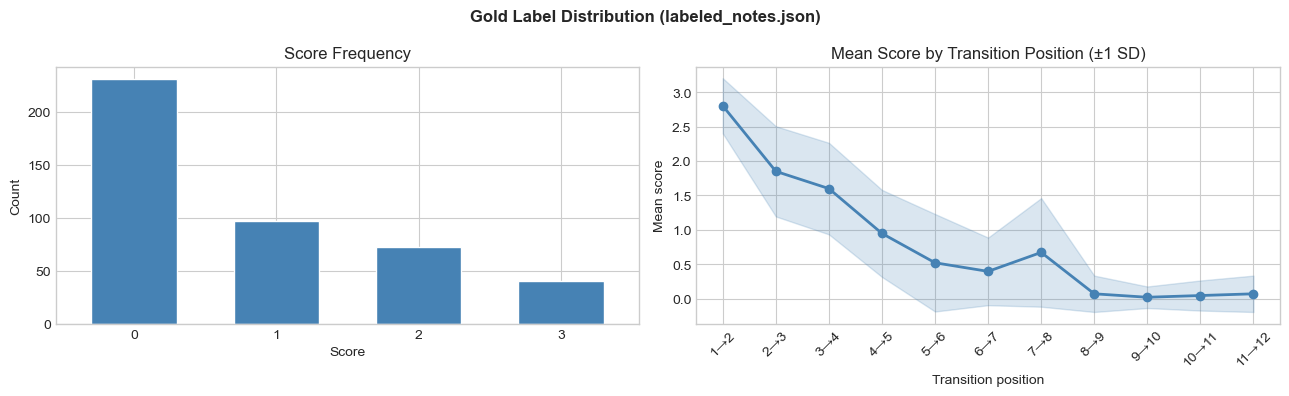

In [59]:
gold = load_gold(GOLD_PATH)
all_scores = [s for scores in gold.values() for s in scores]

print(f"Labeled clients : {len(gold)}")
print(f"Total transitions: {len(all_scores)}")
print(f"Score distribution: {dict(pd.Series(all_scores).value_counts().sort_index())}")
print(f"Mean score: {np.mean(all_scores):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Gold Label Distribution (labeled_notes.json)", fontweight="bold")

# Score distribution
pd.Series(all_scores).value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white", width=0.6)
axes[0].set_xlabel("Score"); axes[0].set_ylabel("Count")
axes[0].set_title("Score Frequency")
axes[0].tick_params(axis="x", rotation=0)

# Per-transition mean
traj_matrix = np.array(list(gold.values()))   # (40, 11)
axes[1].plot(range(1, 12), traj_matrix.mean(axis=0), "o-", color="steelblue", linewidth=2)
axes[1].fill_between(
    range(1, 12),
    traj_matrix.mean(axis=0) - traj_matrix.std(axis=0),
    traj_matrix.mean(axis=0) + traj_matrix.std(axis=0),
    alpha=0.2, color="steelblue",
)
axes[1].set_xlabel("Transition position")
axes[1].set_ylabel("Mean score")
axes[1].set_xticks(range(1, 12))
axes[1].set_xticklabels([f"{i}→{i+1}" for i in range(1, 12)], rotation=45)
axes[1].set_title("Mean Score by Transition Position (±1 SD)")

plt.tight_layout()
plt.show()

## Part (a) — Prompt Development and Validation

### Evaluation approach

Because progress scores are **judgment-based and ordinal** (0 < 1 < 2 < 3), the primary metric
is **Quadratic Weighted Kappa (QWK)**:
- Respects the ordering of labels — a score of 0 predicted as 2 is penalised more than 0 predicted as 1
- Corrects for chance agreement, which matters because score 0 dominates (~52% of transitions)
- The standard metric for ordinal inter-rater agreement tasks

Supporting metrics: exact-match accuracy, MAE (average label distance), within-1 accuracy
(clinically acceptable), and Spearman correlation (rank-order agreement).

---

### V1 Prompt (Baseline)

Minimal instructions — task description, scale, and output format only. No persona, no
definitions, no examples. Full prompt text is in `prompt_v1.txt`.

---

### V2 Prompt (Final)

**Strategies implemented:**
1. **Explicit score definitions** — each label anchored to observable clinical behaviours
2. **Few-shot examples** — 3 labeled clients embedded in the prompt to calibrate the model

Full prompt text is in `prompt_v2.txt`.

### V1 Evaluation (Baseline)

Run the V1 prompt (`prompt_v1.txt`) on `data/test_notes.json` (labeled clients with gold scores stripped).
Save the CSV response as `data/v1_scores.csv`.

Expected header: `client_id,t1_2,t2_3,t3_4,t4_5,t5_6,t6_7,t7_8,t8_9,t9_10,t10_11,t11_12`

In [60]:
v1_pred = load_llm_csv(V1_SCORES_PATH)
y_true_v1, y_pred_v1, step_rows_v1, shared_v1 = align(gold, v1_pred)

print(f"V1 — clients evaluated: {len(shared_v1)}, transitions: {len(y_true_v1)}")
v1_metrics = compute_metrics(y_true_v1, y_pred_v1, label="V1 Baseline")

V1 — clients evaluated: 40, transitions: 440

=== V1 Baseline ===
  QWK (primary) : 0.717
  Accuracy      : 0.695 (69.5%)
  MAE           : 0.370
  Within-1 acc  : 0.934 (93.4%)
  Spearman r    : 0.795


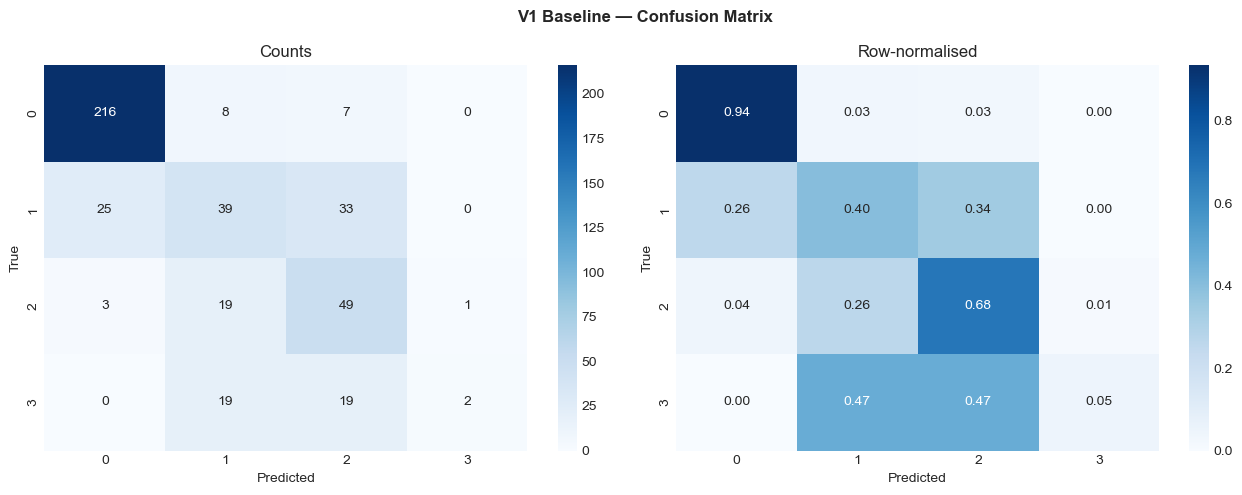

,Pred 0,Pred 1,Pred 2,Pred 3
True 0,216,8,7,0
True 1,25,39,33,0
True 2,3,19,49,1
True 3,0,19,19,2


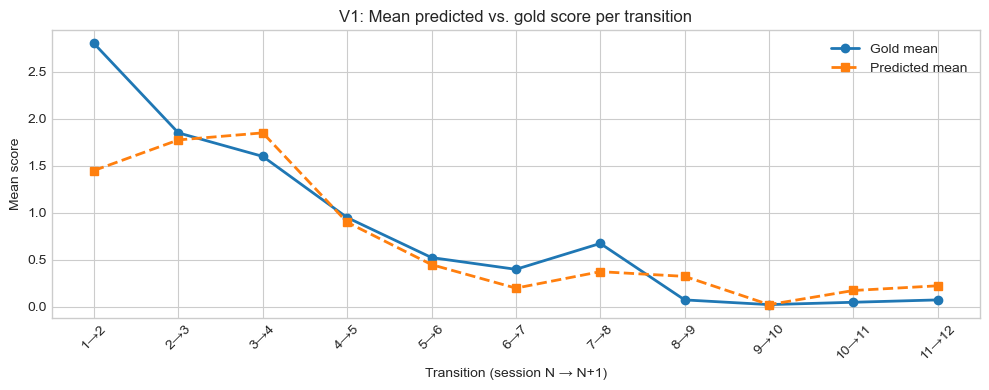

In [61]:
cm_v1 = plot_confusion(y_true_v1, y_pred_v1, title="V1 Baseline — Confusion Matrix")
plot_per_transition(y_true_v1, y_pred_v1, len(shared_v1),
                    title="V1: Mean predicted vs. gold score per transition")

### V2 Evaluation (Final Prompt)

Run the V2 prompt (`prompt_v2.txt`) on `data/test_notes.json`.
Save the CSV response as `data/v2_scores.csv`.

In [62]:
v2_pred = load_llm_csv(V2_SCORES_PATH)
y_true_v2, y_pred_v2, step_rows_v2, shared_v2 = align(gold, v2_pred)

print(f"V2 — clients evaluated: {len(shared_v2)}, transitions: {len(y_true_v2)}")
v2_metrics = compute_metrics(y_true_v2, y_pred_v2, label="V2 Final")

V2 — clients evaluated: 40, transitions: 440

=== V2 Final ===
  QWK (primary) : 0.743
  Accuracy      : 0.725 (72.5%)
  MAE           : 0.336
  Within-1 acc  : 0.939 (93.9%)
  Spearman r    : 0.817


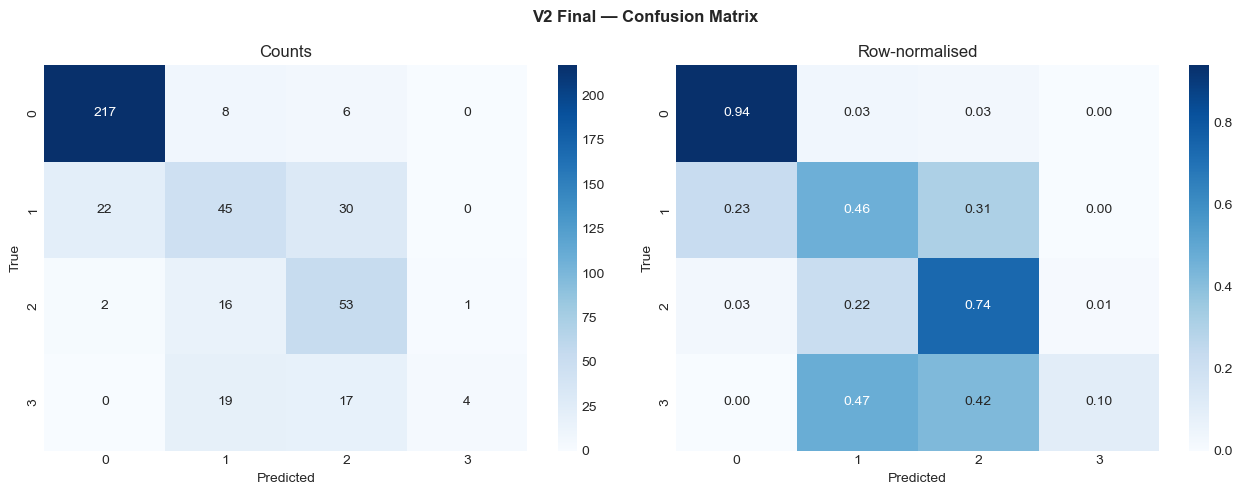

,Pred 0,Pred 1,Pred 2,Pred 3
True 0,217,8,6,0
True 1,22,45,30,0
True 2,2,16,53,1
True 3,0,19,17,4


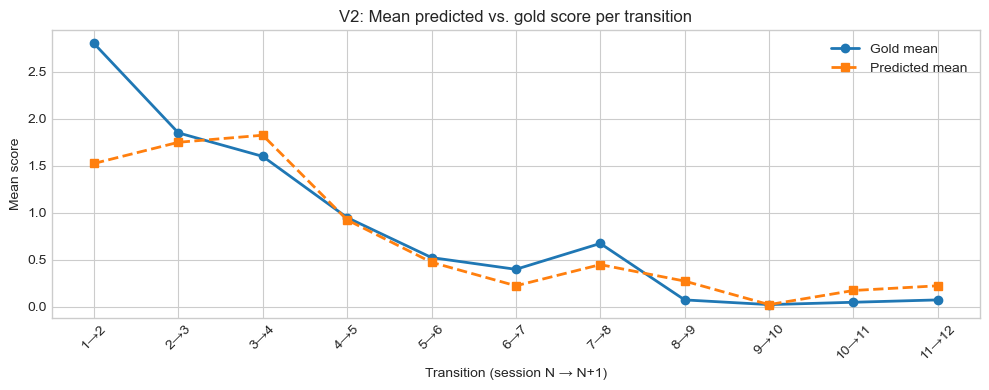

In [63]:
cm_v2 = plot_confusion(y_true_v2, y_pred_v2, title="V2 Final — Confusion Matrix")
plot_per_transition(y_true_v2, y_pred_v2, len(shared_v2),
                    title="V2: Mean predicted vs. gold score per transition")

### Confusion Matrix Interpretation

In [64]:
# ── Auto-generated confusion matrix interpretation ─────────────────────────
from sklearn.metrics import confusion_matrix
import numpy as np

labels = list(VALID_SCORES)
cm = confusion_matrix(y_true_v2, y_pred_v2, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

total = cm.sum()
n_exact = np.diag(cm).sum()
n_within1 = sum(cm[i, j] for i in range(len(labels))
                for j in range(len(labels)) if abs(labels[i] - labels[j]) <= 1)
n_off2plus = total - n_within1

print("=== V2 Confusion Matrix Interpretation ===\n")

for s in labels:
    row_total = cm[s].sum()
    recall = cm_norm[s, s]
    dominant_pred = labels[np.argmax(cm[s])]
    print(f"Score {s} (n={row_total}): recall={recall:.1%}, "
          f"most-predicted-as={dominant_pred}")

print(f"\nExact-match accuracy : {n_exact/total:.1%}  ({n_exact}/{total})")
print(f"Within-1 accuracy    : {n_within1/total:.1%}  ({n_within1}/{total})")
print(f"Off by ≥2            : {n_off2plus} transitions  ({n_off2plus/total:.1%})")

# Bias: is the model over- or under-predicting 0?
pred_0 = cm[:, 0].sum()
true_0 = cm[0].sum()
bias_dir = "over-predicts" if pred_0 > true_0 else "under-predicts"
print(f"\nScore 0 — true count: {true_0}, predicted count: {pred_0} → model {bias_dir} 0")

# Score 3 sparsity
s3_recall = cm_norm[3, 3] if cm[3].sum() > 0 else float('nan')
print(f"Score 3 recall       : {s3_recall:.1%} — "
      + ("model uses score 3 sparingly (as intended)" if s3_recall < 0.5
         else "model assigns score 3 fairly freely"))

=== V2 Confusion Matrix Interpretation ===

Score 0 (n=231): recall=93.9%, most-predicted-as=0
Score 1 (n=97): recall=46.4%, most-predicted-as=1
Score 2 (n=72): recall=73.6%, most-predicted-as=2
Score 3 (n=40): recall=10.0%, most-predicted-as=1

Exact-match accuracy : 72.5%  (319/440)
Within-1 accuracy    : 93.9%  (413/440)
Off by ≥2            : 27 transitions  (6.1%)

Score 0 — true count: 231, predicted count: 241 → model over-predicts 0
Score 3 recall       : 10.0% — model uses score 3 sparingly (as intended)


In [65]:
# ── V1 vs V2 comparison table ─────────────────────────────────────────────
metric_labels = {
    "qwk":      "Quadratic Weighted Kappa",
    "accuracy": "Exact-match accuracy",
    "mae":      "Mean absolute error",
    "within1":  "Within-1 accuracy",
    "spearman": "Spearman correlation",
}

rows = []
for key, label in metric_labels.items():
    v1_val = v1_metrics[key]
    v2_val = v2_metrics[key]
    better = "↑" if (key != "mae" and v2_val > v1_val) or (key == "mae" and v2_val < v1_val) else ""
    rows.append({
        "Metric": label,
        f"V1 ({len(shared_v1)} clients)": f"{v1_val:.3f}",
        f"V2 ({len(shared_v2)} clients)": f"{v2_val:.3f}  {better}",
    })

compare_df = pd.DataFrame(rows)
display(compare_df)

# ── Prompt iteration log ───────────────────────────────────────────────────
print("\nPrompt Iteration Log:")
print(f"  V1 (Baseline) — minimal prompt, no definitions, no examples")
print(f"    QWK: {v1_metrics['qwk']:.3f}")
print(f"  V2 (Final) — explicit scale definitions + few-shot examples")
print(f"    QWK: {v2_metrics['qwk']:.3f}")
delta = v2_metrics['qwk'] - v1_metrics['qwk']
print(f"  Improvement: {delta:+.3f} QWK points")

,Metric,V1 (40 clients),V2 (40 clients)
0,Quadratic Weighted Kappa,0.717,0.743 ↑
1,Exact-match accuracy,0.695,0.725 ↑
2,Mean absolute error,0.370,0.336 ↑
3,Within-1 accuracy,0.934,0.939 ↑
4,Spearman correlation,0.795,0.817 ↑



Prompt Iteration Log:
  V1 (Baseline) — minimal prompt, no definitions, no examples
    QWK: 0.717
  V2 (Final) — explicit scale definitions + few-shot examples
    QWK: 0.743
  Improvement: +0.026 QWK points


## Part (b) — Large-Scale Scoring

Apply the validated V2 prompt to every client in `unlabeled_notes.json`.

**Instructions:**
1. Upload `data/unlabeled_notes.json` to Claude Opus 4.6
2. Paste the V2 prompt from `prompt_v2.txt`
3. Save the CSV response as `data/unlabeled_scores.csv`
4. Run the cells below to produce `data/scored_notes.csv`

Expected header: `client_id,t1_2,t2_3,t3_4,t4_5,t5_6,t6_7,t7_8,t8_9,t9_10,t10_11,t11_12`

In [66]:
# ── Load unlabeled scores and convert to long format ───────────────────────
unlabeled_pred = load_llm_csv(UNLABELED_SCORES_PATH)
print(f"Unlabeled clients scored: {len(unlabeled_pred)}")

# Flatten to long format: client_id | session | score
long_rows = []
for cid in sorted(unlabeled_pred.keys()):
    for j, score in enumerate(unlabeled_pred[cid]):
        long_rows.append({"client_id": cid, "session": j + 2, "score": score})

scored_df = pd.DataFrame(long_rows)
print(f"Long-format rows: {len(scored_df)}")
print(f"Score distribution:")
print(scored_df["score"].value_counts().sort_index().to_string())
scored_df.head()

Unlabeled clients scored: 80
Long-format rows: 880
Score distribution:
score
0    414
1    324
2    142


,client_id,session,score
0,C_001,2,1
1,C_001,3,2
2,C_001,4,2
3,C_001,5,1
4,C_001,6,1


In [67]:
# ── Save scored_notes.csv ─────────────────────────────────────────────────
scored_df.to_csv(SCORED_NOTES_PATH, index=False)
print(f"Saved {len(scored_df)} rows → {SCORED_NOTES_PATH}")
print(f"  Clients : {scored_df['client_id'].nunique()}")
print(f"  Sessions: 11 scored transitions per client (sessions 2–12)")

Saved 880 rows → data/scored_notes.csv
  Clients : 80
  Sessions: 11 scored transitions per client (sessions 2–12)


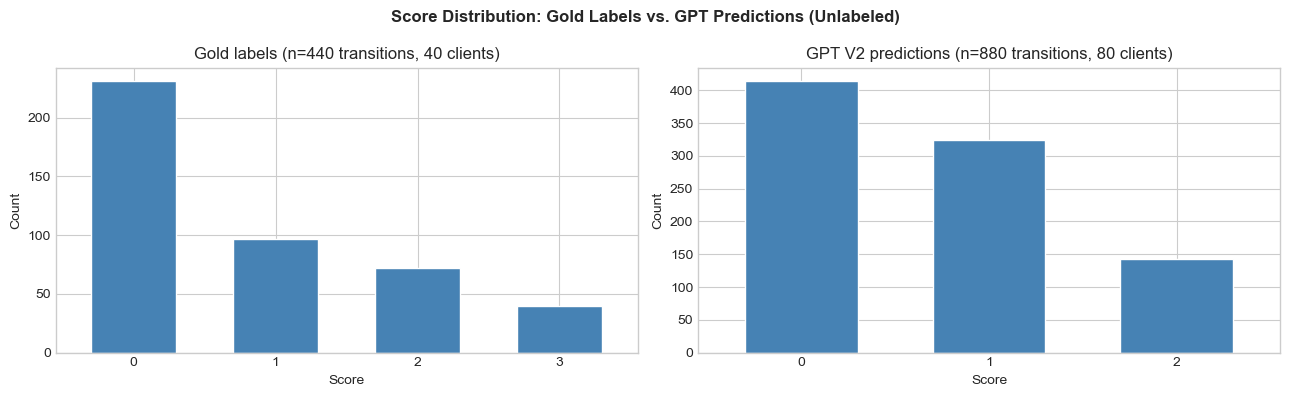

Gold mean score      : 0.820
Unlabeled mean score : 0.691


In [68]:
# ── Sanity check: compare unlabeled prediction distribution vs. gold ───────
gold = load_gold(GOLD_PATH)
gold_scores_flat = [s for scores in gold.values() for s in scores]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Score Distribution: Gold Labels vs. Claude Opus 4.6 Predictions (Unlabeled)",
             fontweight="bold")

for ax, scores, title in zip(
    axes,
    [gold_scores_flat, scored_df["score"].tolist()],
    [f"Gold labels (n={len(gold_scores_flat)} transitions, 40 clients)",
     f"Claude Opus 4.6 predictions (n={len(scored_df)} transitions, {scored_df['client_id'].nunique()} clients)"],
):
    pd.Series(scores).value_counts().sort_index().plot(
        kind="bar", ax=ax, color="steelblue", edgecolor="white", width=0.6)
    ax.set_xlabel("Score"); ax.set_ylabel("Count")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(f"Gold mean score      : {np.mean(gold_scores_flat):.3f}")
print(f"Unlabeled mean score : {scored_df['score'].mean():.3f}")